# 10 — Backtest: Model vs Market

**Goal:** Merge historical BFO odds with model predictions to answer:
1. Does the model beat the closing line?
2. Would the betting strategy have been profitable?
3. How do confidence tiers perform against the market?

**Inputs:**
- `odds_historical.csv` — BFO odds (from NB09)
- `model_data.csv` — features for all fights
- `fights_clean.csv` — results (winner)
- `fighters_clean.csv` — profile fallback
- Production models from NB06
- `best_params.json` — ensemble weights
- `feature_list.txt` — feature columns

Cell 1


In [3]:
import pandas as pd
import numpy as np
import json, os, re, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

# Auto-detect data path
DATA = "./data/" if os.path.exists("./data/odds_historical_2.csv") else "../data/"
MODEL = "./models/" if os.path.exists("./models/") else "../models/"
if not os.path.exists(MODEL + "xgb_prod.json"):
    MODEL = "./models/" if os.path.exists("./models/xgb_prod.json") else "../models/"

print(f"Data path: {DATA}")
print(f"Model path: {MODEL}")

# Load odds
odds = pd.read_csv(f"{DATA}odds_historical_2.csv")
print(f"\nOdds: {len(odds)} fights across {odds['event_name'].nunique()} events")

# Load model data + fights + fighters
model_data = pd.read_csv(f"{DATA}model_data.csv")
fights = pd.read_csv(f"{DATA}fights_clean.csv")
fighters = pd.read_csv(f"{DATA}fighters_clean.csv")

# Load features
with open(f"{DATA}feature_list.txt") as f:
    FEATURES = [line.strip() for line in f if line.strip()]
print(f"Features: {len(FEATURES)}")

# Load ensemble weights
with open(f"{DATA}best_params.json") as f:
    bp = json.load(f)
W = bp.get('ensemble_weights', {'xgb': 1/3, 'lgb': 1/3, 'cat': 1/3})
print(f"Ensemble weights: { {k: round(v,3) for k,v in W.items()} }")

# Load production models
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(f"{MODEL}xgb_tuned.json")

lgb_model = lgb.Booster(model_file=f"{MODEL}lgb_tuned.txt")

cat_model = cb.CatBoostClassifier()
cat_model.load_model(f"{MODEL}cat_tuned.cbm")

print("\nAll models loaded.")

Data path: ./data/
Model path: ../models/

Odds: 59 fights across 8 events
Features: 310
Ensemble weights: {'xgb': 0.333, 'lgb': 0.333, 'cat': 0.333}

All models loaded.


Cell 2

In [4]:
# Clean event names — strip "Odds" suffix and normalize
odds['event_clean'] = odds['event_name'].str.replace(r'\s*Odds.*', '', regex=True).str.strip()
odds['ufc_num'] = odds['event_clean'].str.extract(r'UFC\s*(\d+)').astype(float)

print(f"Before dedup: {len(odds)} fights")

# Deduplicate: same event + overlapping fighter names (e.g. Lipski / da Silva + Wang Cong / Cong Wang)
# Strategy: within each event, flag fights where fighter names are substrings of another fight's names
dupes_to_drop = []
for evt, grp in odds.groupby('event_clean'):
    rows = grp.reset_index()
    for i in range(len(rows)):
        for j in range(i+1, len(rows)):
            names_i = set(rows.loc[i, 'fighter_1'].lower().split() + rows.loc[i, 'fighter_2'].lower().split())
            names_j = set(rows.loc[j, 'fighter_1'].lower().split() + rows.loc[j, 'fighter_2'].lower().split())
            overlap = len(names_i & names_j)
            if overlap >= 2:  # at least 2 name tokens in common
                # drop the one with fewer books
                if rows.loc[i, 'n_books_1'] >= rows.loc[j, 'n_books_1']:
                    dupes_to_drop.append(rows.loc[j, 'index'])
                else:
                    dupes_to_drop.append(rows.loc[i, 'index'])

if dupes_to_drop:
    print(f"Dropping {len(dupes_to_drop)} duplicate(s):")
    for idx in dupes_to_drop:
        row = odds.loc[idx]
        print(f"  {row['event_clean']}: {row['fighter_1']} vs {row['fighter_2']}")
    odds = odds.drop(index=dupes_to_drop).reset_index(drop=True)

print(f"After dedup: {len(odds)} fights across {odds['event_clean'].nunique()} events")
print()

# Coverage per event
cov = odds.groupby('event_clean').agg(
    fights=('fighter_1', 'size'),
    avg_overround=('overround', 'mean')
).reset_index()
print(cov.to_string(index=False))

Before dedup: 59 fights
After dedup: 59 fights across 8 events

event_clean  fights  avg_overround
    UFC 319       9       1.048233
    UFC 320       5       1.047296
    UFC 321      13       1.074965
    UFC 322      12       1.040581
    UFC 323       2       1.045231
    UFC 324       3       1.009367
    UFC 326       3       1.048993
    UFC 327      12       1.086846


Cell 3

In [5]:
# We need to match each BFO fight to a row in model_data
# BFO names may differ from UFCStats names (e.g. "Du Plessis" vs "du Plessis")

# Build lookup from model_data: last fight per fighter pair
# model_data has fighter_1, fighter_2, event_date, f1_win
model_data['event_date'] = pd.to_datetime(model_data['event_date'])
fights['event_date'] = pd.to_datetime(fights['event_date'])

# Normalize names for matching
def normalize_name(name):
    if pd.isna(name):
        return ''
    name = str(name).strip().lower()
    name = re.sub(r'[^a-z\s]', '', name)  # remove non-alpha
    name = re.sub(r'\s+', ' ', name)       # collapse spaces
    return name

# Build a mapping: for each fight in model_data, create normalized name keys
model_data['f1_norm'] = model_data['fighter_1'].apply(normalize_name)
model_data['f2_norm'] = model_data['fighter_2'].apply(normalize_name)

# Also get results from fights_clean
fights['f1_norm'] = fights['fighter_1'].apply(normalize_name)
fights['f2_norm'] = fights['fighter_2'].apply(normalize_name)

# For each odds row, try to find matching model_data row
# Match by: event_name contains UFC number AND normalized fighter names match
# Fighter order may differ between BFO and UFCStats

odds['f1_norm'] = odds['fighter_1'].apply(normalize_name)
odds['f2_norm'] = odds['fighter_2'].apply(normalize_name)

def fuzzy_name_match(bfo_name, ufcstats_name):
    """Check if names match — exact or subset of tokens."""
    if bfo_name == ufcstats_name:
        return True
    bfo_tokens = set(bfo_name.split())
    ufc_tokens = set(ufcstats_name.split())
    if not bfo_tokens or not ufc_tokens:
        return False
    # last name match + at least one other token
    if len(bfo_tokens & ufc_tokens) >= max(1, min(len(bfo_tokens), len(ufc_tokens)) - 1):
        return True
    return False

matched = []
unmatched = []

for idx, orow in odds.iterrows():
    ufc_num = orow['ufc_num']
    bfo_f1 = orow['f1_norm']
    bfo_f2 = orow['f2_norm']
    
    # Find matching fights in model_data by UFC number in event_name
    candidates = model_data[
        model_data['event_name'].str.contains(f'UFC {int(ufc_num)}', case=False, na=False)
    ] if not np.isnan(ufc_num) else pd.DataFrame()
    
    found = False
    for _, crow in candidates.iterrows():
        ufc_f1 = crow['f1_norm']
        ufc_f2 = crow['f2_norm']
        
        # Check both orderings
        if (fuzzy_name_match(bfo_f1, ufc_f1) and fuzzy_name_match(bfo_f2, ufc_f2)):
            matched.append({**orow.to_dict(), 'md_index': crow.name, 'swapped': False})
            found = True
            break
        elif (fuzzy_name_match(bfo_f1, ufc_f2) and fuzzy_name_match(bfo_f2, ufc_f1)):
            matched.append({**orow.to_dict(), 'md_index': crow.name, 'swapped': True})
            found = True
            break
    
    if not found:
        unmatched.append(orow.to_dict())

print(f"Matched: {len(matched)} / {len(odds)}")
if unmatched:
    print(f"\nUnmatched ({len(unmatched)}):")
    for u in unmatched:
        print(f"  {u['event_clean']}: {u['fighter_1']} vs {u['fighter_2']}")

matched_df = pd.DataFrame(matched)
print(f"\nMatched fights per event:")
print(matched_df.groupby('event_clean').size().to_string())

Matched: 56 / 59

Unmatched (3):
  UFC 321: Ciryl Gane vs Tom Aspinall
  UFC 324: Alexander Hernandez vs Michael Johnson
  UFC 327: Chris Padilla vs Marquel Mederos

Matched fights per event:
event_clean
UFC 319     9
UFC 320     5
UFC 321    12
UFC 322    12
UFC 323     2
UFC 324     2
UFC 326     3
UFC 327    11


Cell 4

In [6]:
# For each matched fight, pull features from model_data and run predictions

results = []

for _, mrow in matched_df.iterrows():
    md_idx = int(mrow['md_index'])
    swapped = mrow['swapped']
    md_row = model_data.loc[md_idx]
    
    # Get features — keep dtypes by slicing the DataFrame directly
    X_df = model_data.loc[[md_idx], FEATURES].copy()
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    
    # Predict P(f1_win)
    p_xgb = xgb_model.predict_proba(X_df)[:, 1][0]
    p_lgb = lgb_model.predict(X_df)[0]  # Booster returns probability directly
    p_cat = cat_model.predict_proba(X_df)[:, 1][0]
    
    p_ens = W['xgb'] * p_xgb + W['lgb'] * p_lgb + W['cat'] * p_cat
    
    # If BFO order was swapped relative to UFCStats, flip probabilities
    # p_ens is P(ufcstats_f1 wins)
    # If swapped: BFO_f1 = UFCStats_f2, so P(BFO_f1 wins) = 1 - p_ens
    if swapped:
        p_bfo_f1 = 1 - p_ens
        p_xgb_bfo = 1 - p_xgb
        p_lgb_bfo = 1 - p_lgb
        p_cat_bfo = 1 - p_cat
    else:
        p_bfo_f1 = p_ens
        p_xgb_bfo = p_xgb
        p_lgb_bfo = p_lgb
        p_cat_bfo = p_cat
    
    p_bfo_f2 = 1 - p_bfo_f1
    
    # Model picks
    pick_xgb = mrow['fighter_1'] if p_xgb_bfo > 0.5 else mrow['fighter_2']
    pick_lgb = mrow['fighter_1'] if p_lgb_bfo > 0.5 else mrow['fighter_2']
    pick_cat = mrow['fighter_1'] if p_cat_bfo > 0.5 else mrow['fighter_2']
    
    picks = [pick_xgb, pick_lgb, pick_cat]
    unanimous = (len(set(picks)) == 1)
    
    model_pick = mrow['fighter_1'] if p_bfo_f1 > 0.5 else mrow['fighter_2']
    model_conf = max(p_bfo_f1, p_bfo_f2)
    
    # Confidence tier
    if not unanimous:
        tier = 'NO_CONF'
    elif model_conf >= 0.80:
        tier = 'VERY_HIGH'
    elif model_conf >= 0.65:
        tier = 'HIGH'
    elif model_conf >= 0.55:
        tier = 'MEDIUM'
    else:
        tier = 'LOW'
    
    # Actual result from fights_clean
    actual_winner = md_row.get('winner', None)
    f1_win = md_row.get('f1_win', None)
    
    # Map result to BFO fighter order
    if swapped:
        bfo_f1_won = (f1_win == 0)  # BFO_f1 = UFCStats_f2
    else:
        bfo_f1_won = (f1_win == 1)
    
    actual_winner_bfo = mrow['fighter_1'] if bfo_f1_won else mrow['fighter_2']
    model_correct = (model_pick == actual_winner_bfo)
    
    results.append({
        'event': mrow['event_clean'],
        'ufc_num': mrow['ufc_num'],
        'fighter_1': mrow['fighter_1'],
        'fighter_2': mrow['fighter_2'],
        'odds_1': mrow['odds_1_avg'],
        'odds_2': mrow['odds_2_avg'],
        'fair_1': mrow['fair_1'],
        'fair_2': mrow['fair_2'],
        'model_p1': round(p_bfo_f1, 4),
        'model_p2': round(p_bfo_f2, 4),
        'p_xgb': round(p_xgb_bfo, 4),
        'p_lgb': round(p_lgb_bfo, 4),
        'p_cat': round(p_cat_bfo, 4),
        'model_pick': model_pick,
        'unanimous': unanimous,
        'confidence': round(model_conf, 4),
        'tier': tier,
        'actual_winner': actual_winner_bfo,
        'correct': model_correct,
        'swapped': swapped,
    })

res = pd.DataFrame(results)
print(f"Predictions generated: {len(res)} fights")
print(f"\nOverall accuracy: {res['correct'].mean():.1%} ({res['correct'].sum()}/{len(res)})")
print(f"\nPer event:")
evt_acc = res.groupby('event').agg(
    fights=('correct', 'size'),
    correct=('correct', 'sum'),
    accuracy=('correct', 'mean')
).reset_index()
evt_acc['accuracy'] = evt_acc['accuracy'].apply(lambda x: f"{x:.1%}")
print(evt_acc.to_string(index=False))

Predictions generated: 56 fights

Overall accuracy: 85.7% (48/56)

Per event:
  event  fights  correct accuracy
UFC 319       9        8    88.9%
UFC 320       5        4    80.0%
UFC 321      12        9    75.0%
UFC 322      12       11    91.7%
UFC 323       2        2   100.0%
UFC 324       2        2   100.0%
UFC 326       3        3   100.0%
UFC 327      11        9    81.8%


Cell 5

MODEL ACCURACY BY CONFIDENCE TIER × UNANIMITY

Tier         Group         Fights  Correct  Accuracy  Avg Conf
------------------------------------------------------------
VERY_HIGH    ALL               15       14    93.3%    87.7%
VERY_HIGH    Unanimous         15       14    93.3%    87.7%

HIGH         ALL               25       19    76.0%    71.2%
HIGH         Unanimous         25       19    76.0%    71.2%

MEDIUM       ALL               10        9    90.0%    59.7%
MEDIUM       Unanimous         10        9    90.0%    59.7%

NO_CONF      ALL                6        6   100.0%    54.0%
NO_CONF      Split              6        6   100.0%    54.0%

TOTAL        Unanimous         50       42    84.0%
TOTAL        Split              6        6   100.0%
TOTAL        ALL               56       48    85.7%

SPLIT PICK DETAILS — MODEL DISAGREEMENTS

Event        Fighter 1            Fighter 2               XGB    LGB    CAT Dissenter Winner               Dissenter Right?
--------------

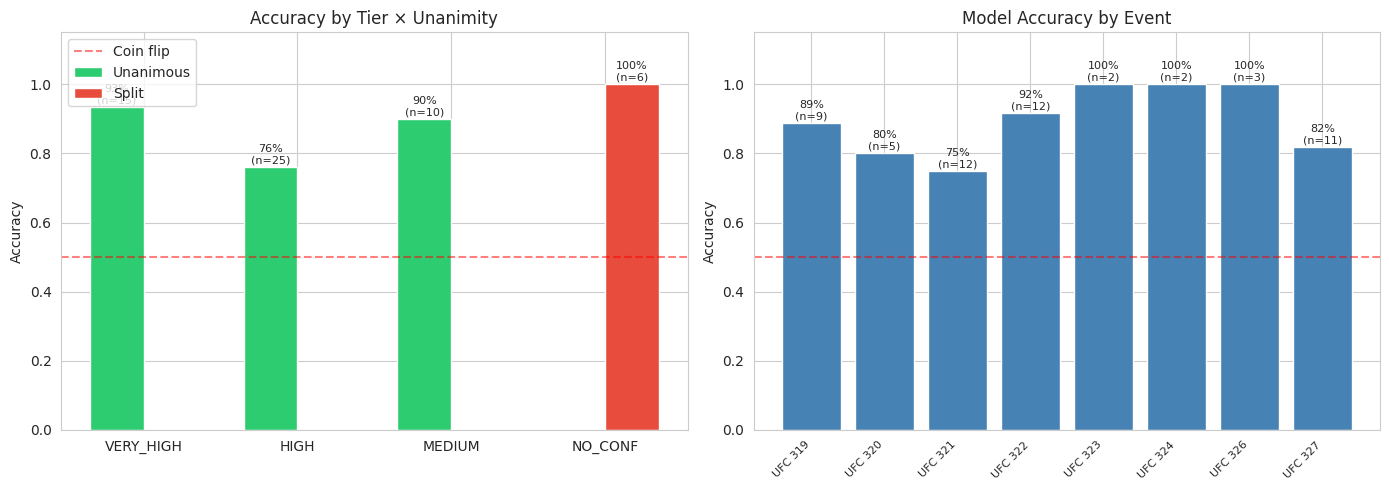

Saved: ./data/backtest_accuracy.png


In [7]:
print("=" * 70)
print("MODEL ACCURACY BY CONFIDENCE TIER × UNANIMITY")
print("=" * 70)

tier_order = ['VERY_HIGH', 'HIGH', 'MEDIUM', 'LOW', 'NO_CONF']
res['unan_label'] = res['unanimous'].map({True: 'Unanimous', False: 'Split'})

# Cross-tab: tier × unanimous
cross = res.groupby(['tier', 'unan_label']).agg(
    fights=('correct', 'size'),
    correct=('correct', 'sum'),
    accuracy=('correct', 'mean'),
    avg_conf=('confidence', 'mean')
).reset_index()

tier_totals = res.groupby('tier').agg(
    fights=('correct', 'size'),
    correct=('correct', 'sum'),
    accuracy=('correct', 'mean'),
    avg_conf=('confidence', 'mean')
).reindex(tier_order).dropna(how='all').reset_index()
tier_totals['unan_label'] = 'ALL'

combined = pd.concat([cross, tier_totals], ignore_index=True)
combined['tier'] = pd.Categorical(combined['tier'], categories=tier_order, ordered=True)
combined = combined.sort_values(['tier', 'unan_label']).reset_index(drop=True)

print(f"\n{'Tier':<12} {'Group':<12} {'Fights':>7} {'Correct':>8} {'Accuracy':>9} {'Avg Conf':>9}")
print("-" * 60)
prev_tier = None
for _, row in combined.iterrows():
    if row['tier'] != prev_tier and prev_tier is not None:
        print()
    print(f"{row['tier']:<12} {row['unan_label']:<12} {int(row['fights']):>7} {int(row['correct']):>8} "
          f"{row['accuracy']:>8.1%} {row['avg_conf']:>8.1%}")
    prev_tier = row['tier']

# Grand totals
unan = res[res['unanimous']]
split = res[~res['unanimous']]
print(f"\n{'='*60}")
print(f"{'TOTAL':<12} {'Unanimous':<12} {len(unan):>7} {int(unan['correct'].sum()):>8} "
      f"{unan['correct'].mean():>8.1%}")
if len(split) > 0:
    print(f"{'TOTAL':<12} {'Split':<12} {len(split):>7} {int(split['correct'].sum()):>8} "
          f"{split['correct'].mean():>8.1%}")
print(f"{'TOTAL':<12} {'ALL':<12} {len(res):>7} {int(res['correct'].sum()):>8} "
      f"{res['correct'].mean():>8.1%}")

# ── Detailed disagreement breakdown for split picks ──
if len(split) > 0:
    print(f"\n{'='*70}")
    print("SPLIT PICK DETAILS — MODEL DISAGREEMENTS")
    print(f"{'='*70}")
    
    # Determine which model(s) dissented
    split_detail = split.copy()
    split_detail['xgb_pick'] = split_detail.apply(
        lambda r: r['fighter_1'] if r['p_xgb'] > 0.5 else r['fighter_2'], axis=1)
    split_detail['lgb_pick'] = split_detail.apply(
        lambda r: r['fighter_1'] if r['p_lgb'] > 0.5 else r['fighter_2'], axis=1)
    split_detail['cat_pick'] = split_detail.apply(
        lambda r: r['fighter_1'] if r['p_cat'] > 0.5 else r['fighter_2'], axis=1)
    
    # Who was the odd one out?
    def find_dissenter(row):
        picks = {'XGB': row['xgb_pick'], 'LGB': row['lgb_pick'], 'CAT': row['cat_pick']}
        from collections import Counter
        counts = Counter(picks.values())
        majority_pick = counts.most_common(1)[0][0]
        dissenters = [k for k, v in picks.items() if v != majority_pick]
        return ', '.join(dissenters), majority_pick
    
    split_detail['dissenter'], split_detail['majority_pick'] = zip(
        *split_detail.apply(find_dissenter, axis=1))
    
    # Was the dissenter right?
    split_detail['dissenter_correct'] = split_detail.apply(
        lambda r: r['actual_winner'] != r['majority_pick'], axis=1)
    
    print(f"\n{'Event':<12} {'Fighter 1':<20} {'Fighter 2':<20} "
          f"{'XGB':>6} {'LGB':>6} {'CAT':>6} {'Dissenter':<6} {'Winner':<20} {'Dissenter Right?'}")
    print("-" * 120)
    
    for _, r in split_detail.iterrows():
        # Show each model's probability for fighter_1
        xgb_str = f"{r['p_xgb']:.0%}"
        lgb_str = f"{r['p_lgb']:.0%}"
        cat_str = f"{r['p_cat']:.0%}"
        
        dissenter_right = "✅ YES" if r['dissenter_correct'] else "❌ NO"
        
        print(f"{r['event']:<12} {r['fighter_1']:<20} {r['fighter_2']:<20} "
              f"{xgb_str:>6} {lgb_str:>6} {cat_str:>6} {r['dissenter']:<6} "
              f"{r['actual_winner']:<20} {dissenter_right}")
    
    # Dissenter accuracy summary
    print(f"\n--- Dissenter Summary ---")
    dissenter_counts = {}
    dissenter_right_counts = {}
    for _, r in split_detail.iterrows():
        for d in r['dissenter'].split(', '):
            d = d.strip()
            dissenter_counts[d] = dissenter_counts.get(d, 0) + 1
            if r['dissenter_correct']:
                dissenter_right_counts[d] = dissenter_right_counts.get(d, 0) + 1
    
    print(f"\n{'Model':<8} {'Times Dissented':>16} {'Dissenter Was Right':>20} {'Pct':>8}")
    print("-" * 55)
    for model in ['XGB', 'LGB', 'CAT']:
        n_dissent = dissenter_counts.get(model, 0)
        n_right = dissenter_right_counts.get(model, 0)
        pct = f"{n_right/n_dissent:.0%}" if n_dissent > 0 else "N/A"
        print(f"{model:<8} {n_dissent:>16} {n_right:>20} {pct:>8}")
    
    # Majority vs dissenter overall
    majority_correct = len(split_detail) - split_detail['dissenter_correct'].sum()
    dissenter_correct = split_detail['dissenter_correct'].sum()
    print(f"\nMajority (2-model consensus) correct: {majority_correct}/{len(split_detail)} "
          f"({majority_correct/len(split_detail):.0%})")
    print(f"Dissenter (lone model) correct:        {dissenter_correct}/{len(split_detail)} "
          f"({dissenter_correct/len(split_detail):.0%})")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bars — unanimous vs split per tier
tiers_present = [t for t in tier_order if t in res['tier'].values]
x = np.arange(len(tiers_present))
width = 0.35

unan_acc, split_acc, unan_n, split_n = [], [], [], []
for t in tiers_present:
    u = res[(res['tier'] == t) & (res['unanimous'])]
    s = res[(res['tier'] == t) & (~res['unanimous'])]
    unan_acc.append(u['correct'].mean() if len(u) > 0 else 0)
    split_acc.append(s['correct'].mean() if len(s) > 0 else 0)
    unan_n.append(len(u))
    split_n.append(len(s))

bars1 = axes[0].bar(x - width/2, unan_acc, width, label='Unanimous', color='#2ecc71', edgecolor='white')
bars2 = axes[0].bar(x + width/2, split_acc, width, label='Split', color='#e74c3c', edgecolor='white')

for i, (b, n) in enumerate(zip(bars1, unan_n)):
    if n > 0:
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                     f"{unan_acc[i]:.0%}\n(n={n})", ha='center', fontsize=8)
for i, (b, n) in enumerate(zip(bars2, split_n)):
    if n > 0:
        axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                     f"{split_acc[i]:.0%}\n(n={n})", ha='center', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(tiers_present)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Tier × Unanimity')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Coin flip')
axes[0].set_ylim(0, 1.15)
axes[0].legend()

# Right: accuracy by event
evt_plot = res.groupby('event').agg(accuracy=('correct', 'mean'), n=('correct', 'size')).reset_index()
evt_plot = evt_plot.sort_values('event')
bars3 = axes[1].bar(range(len(evt_plot)), evt_plot['accuracy'], color='steelblue')
for i, (_, row) in enumerate(evt_plot.iterrows()):
    axes[1].text(i, row['accuracy'] + 0.01, f"{row['accuracy']:.0%}\n(n={int(row['n'])})",
                 ha='center', fontsize=8)
axes[1].set_xticks(range(len(evt_plot)))
axes[1].set_xticklabels(evt_plot['event'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy by Event')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(f"{DATA}backtest_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA}backtest_accuracy.png")

Cell 6

BETTING SIMULATION — MULTIPLE STRATEGIES

Qualified bets: 33
Record: 30W - 3L (90.9%)
Avg edge: 17.5%
Avg odds: -165

Strategy                         Staked        P&L      ROI  Avg Stake  Max Stake
Quarter Kelly (5% cap)       $   133.50 $   +70.21   +52.6% $     4.05 $     5.00
Half Kelly (10% cap)         $   267.01 $  +140.42   +52.6% $     8.09 $    10.00
Full Kelly (20% cap)         $   534.01 $  +280.84   +52.6% $    16.18 $    20.00
Flat 1%                      $    33.00 $   +17.50   +53.0% $     1.00 $     1.00
Flat 2%                      $    66.00 $   +35.00   +53.0% $     2.00 $     2.00
Flat 5%                      $   165.00 $   +87.49   +53.0% $     5.00 $     5.00
Edge Proportional            $    92.04 $   +54.77   +59.5% $     2.79 $     5.00
Edge Prop ×2 (16% cap)       $   184.08 $  +109.54   +59.5% $     5.58 $    10.00
Edge Prop ² (12% cap)        $   148.16 $   +83.64   +56.5% $     4.49 $    12.00
Confidence Tiered            $    97.50 $   +41.60   +42.7% $ 

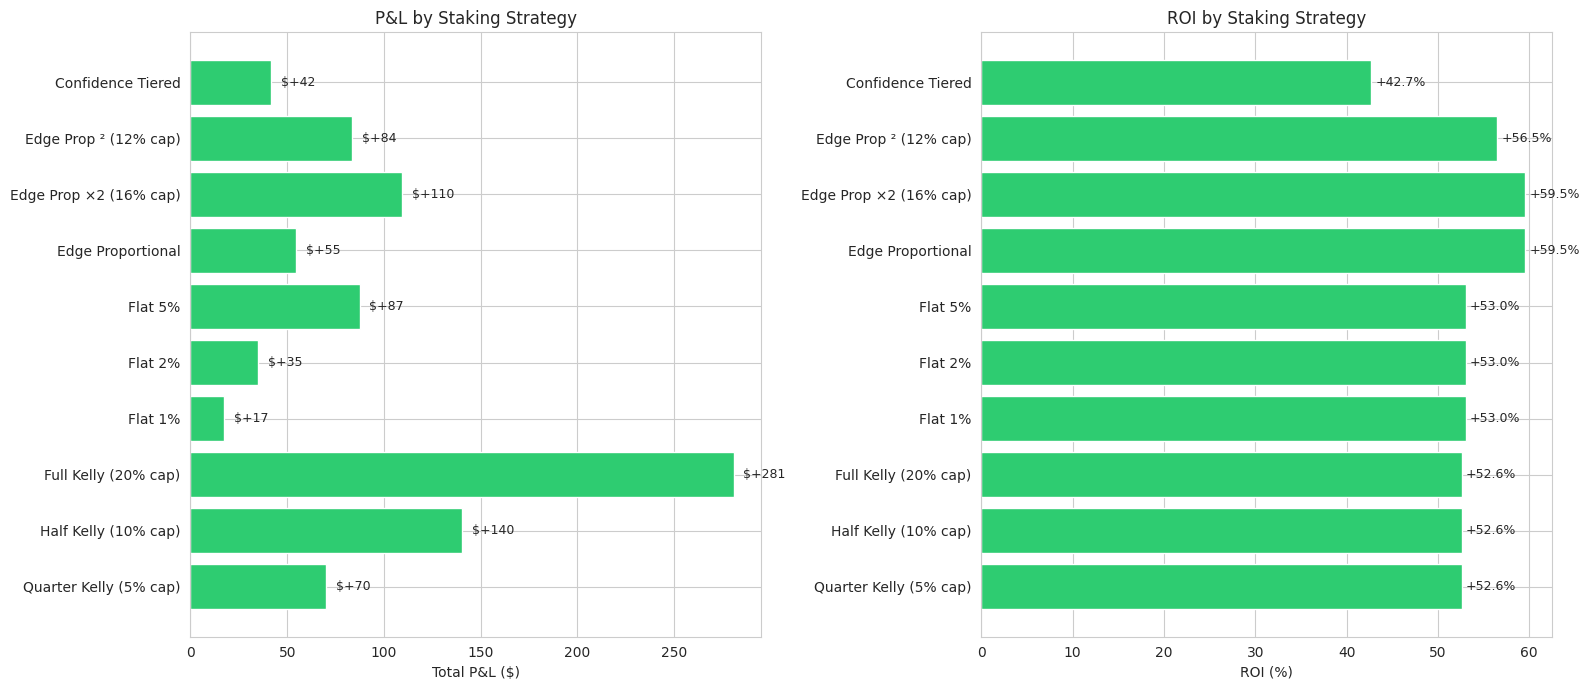

Saved: ./data/backtest_strategies_staking.png


In [8]:
print("=" * 70)
print("BETTING SIMULATION — MULTIPLE STRATEGIES")
print("=" * 70)

def american_to_decimal(odds):
    if odds > 0:
        return 1 + odds / 100
    else:
        return 1 + 100 / abs(odds)

# Build bet analysis for every fight
bets = []

for _, row in res.iterrows():
    if row['model_p1'] >= row['model_p2']:
        pick = row['fighter_1']
        model_prob = row['model_p1']
        market_fair = row['fair_1']
        american_odds = row['odds_1']
    else:
        pick = row['fighter_2']
        model_prob = row['model_p2']
        market_fair = row['fair_2']
        american_odds = row['odds_2']
    
    decimal_odds = american_to_decimal(american_odds)
    edge = model_prob - market_fair
    won = (pick == row['actual_winner'])
    qualifies = (row['unanimous'] and row['confidence'] >= 0.55 and edge > 0)
    
    abs_odds = abs(american_odds)
    if american_odds > 0:
        odds_bucket = 'Underdog (+100 or more)'
    elif abs_odds <= 150:
        odds_bucket = 'Slight Fav (-100 to -150)'
    elif abs_odds <= 250:
        odds_bucket = 'Moderate Fav (-151 to -250)'
    else:
        odds_bucket = 'Heavy Fav (-251 or more)'
    
    bets.append({
        **row.to_dict(),
        'pick': pick,
        'model_prob': model_prob,
        'market_fair': market_fair,
        'american_odds': american_odds,
        'decimal_odds': round(decimal_odds, 4),
        'edge': round(edge, 4),
        'won': won,
        'qualifies': qualifies,
        'odds_bucket': odds_bucket,
    })

BANKROLL = 100
bets_df = pd.DataFrame(bets)
qualified = bets_df[bets_df['qualifies']].copy()

def calc_stakes(df, bankroll, method):
    results = []
    for _, row in df.iterrows():
        edge = row['edge']
        dec_odds = row['decimal_odds']
        
        if method == 'half_kelly':
            frac = (edge / (dec_odds - 1)) / 2
            frac = min(frac, 0.10)
            stake = frac * bankroll
        elif method == 'quarter_kelly':
            frac = (edge / (dec_odds - 1)) / 4
            frac = min(frac, 0.05)
            stake = frac * bankroll
        elif method == 'full_kelly':
            frac = edge / (dec_odds - 1)
            frac = min(frac, 0.20)
            stake = frac * bankroll
        elif method == 'flat_1pct':
            stake = bankroll * 0.01
        elif method == 'flat_2pct':
            stake = bankroll * 0.02
        elif method == 'flat_5pct':
            stake = bankroll * 0.05
        elif method == 'edge_proportional':
            frac = (edge / 0.10) * 0.02
            if dec_odds >= 3.0:
                cap = 0.03
            elif dec_odds >= 2.0:
                cap = 0.05
            else:
                cap = 0.08
            frac = max(0.005, min(frac, cap))
            stake = frac * bankroll
        elif method == 'edge_proportional_2x':
            frac = (edge / 0.10) * 0.04
            if dec_odds >= 3.0:
                cap = 0.06
            elif dec_odds >= 2.0:
                cap = 0.10
            else:
                cap = 0.16
            frac = max(0.01, min(frac, cap))
            stake = frac * bankroll
        elif method == 'edge_proportional_sq':
            frac = ((edge ** 2) / (0.10 ** 2)) * 0.02
            if dec_odds >= 3.0:
                cap = 0.04
            elif dec_odds >= 2.0:
                cap = 0.08
            else:
                cap = 0.12
            frac = max(0.005, min(frac, cap))
            stake = frac * bankroll
        elif method == 'confidence_tiered':
            tier = row.get('tier', 'MEDIUM')
            tier_map = {'VERY_HIGH': 0.04, 'HIGH': 0.025, 'MEDIUM': 0.015, 'LOW': 0.01}
            frac = tier_map.get(tier, 0.01)
            stake = frac * bankroll
        else:
            stake = 0
        
        pnl = stake * (dec_odds - 1) if row['won'] else -stake
        results.append({'stake': stake, 'pnl': pnl})
    
    return pd.DataFrame(results)

# ── All strategies for summary table ──
all_strategies = {
    'Quarter Kelly (5% cap)': 'quarter_kelly',
    'Half Kelly (10% cap)': 'half_kelly',
    'Full Kelly (20% cap)': 'full_kelly',
    'Flat 1%': 'flat_1pct',
    'Flat 2%': 'flat_2pct',
    'Flat 5%': 'flat_5pct',
    'Edge Proportional': 'edge_proportional',
    'Edge Prop ×2 (16% cap)': 'edge_proportional_2x',
    'Edge Prop ² (12% cap)': 'edge_proportional_sq',
    'Confidence Tiered': 'confidence_tiered',
}

print(f"\nQualified bets: {len(qualified)}")
print(f"Record: {int(qualified['won'].sum())}W - {int((~qualified['won']).sum())}L ({qualified['won'].mean():.1%})")
print(f"Avg edge: {qualified['edge'].mean():.1%}")
print(f"Avg odds: {qualified['american_odds'].mean():+.0f}")

print(f"\n{'Strategy':<28} {'Staked':>10} {'P&L':>10} {'ROI':>8} {'Avg Stake':>10} {'Max Stake':>10}")
print("=" * 80)

strategy_results = {}
for name, method in all_strategies.items():
    stk = calc_stakes(qualified, BANKROLL, method)
    total_staked = stk['stake'].sum()
    total_pnl = stk['pnl'].sum()
    roi = total_pnl / total_staked * 100 if total_staked > 0 else 0
    avg_stake = stk['stake'].mean()
    max_stake = stk['stake'].max()
    strategy_results[name] = {
        'staked': total_staked, 'pnl': total_pnl, 'roi': roi,
        'avg_stake': avg_stake, 'max_stake': max_stake, 'stakes': stk
    }
    print(f"{name:<28} ${total_staked:>9.2f} ${total_pnl:>+9.2f} {roi:>+7.1f}% ${avg_stake:>9.2f} ${max_stake:>9.2f}")

# ── Per-fight breakdown: HK, FK, EP, EP×2, EP² ──
detail_methods = {
    'hk': 'half_kelly',
    'fk': 'full_kelly',
    'ep': 'edge_proportional',
    'ep2x': 'edge_proportional_2x',
    'epsq': 'edge_proportional_sq',
}

qualified = qualified.copy()
for key, method in detail_methods.items():
    stk = calc_stakes(qualified, BANKROLL, method)
    qualified[f'{key}_stake'] = stk['stake'].values
    qualified[f'{key}_pnl'] = stk['pnl'].values

print(f"\n{'='*195}")
print(f"{'Event':<12} {'Pick':<22} {'Odds':>6} {'Mod':>5} {'Mkt':>5} {'Edge':>5} "
      f"{'HK $':>7} {'HK PL':>7} {'FK $':>7} {'FK PL':>7} "
      f"{'EP $':>7} {'EP PL':>7} {'2x $':>7} {'2x PL':>7} "
      f"{'² $':>7} {'² PL':>7} {'':>5}")
print(f"{'='*195}")

for evt in sorted(qualified['event'].unique()):
    evt_bets = qualified[qualified['event'] == evt].sort_values('edge', ascending=False)
    for _, b in evt_bets.iterrows():
        r = 'W ✅' if b['won'] else 'L ❌'
        print(f"{b['event']:<12} {b['pick']:<22} {b['american_odds']:>+6.0f} "
              f"{b['model_prob']:>4.0%} {b['market_fair']:>4.0%} {b['edge']:>+4.0%} "
              f"${b['hk_stake']:>6.1f} ${b['hk_pnl']:>+6.1f} "
              f"${b['fk_stake']:>6.1f} ${b['fk_pnl']:>+6.1f} "
              f"${b['ep_stake']:>6.1f} ${b['ep_pnl']:>+6.1f} "
              f"${b['ep2x_stake']:>6.1f} ${b['ep2x_pnl']:>+6.1f} "
              f"${b['epsq_stake']:>6.1f} ${b['epsq_pnl']:>+6.1f} {r}")
    # Event totals
    print(f"{'':>12} {'':>22} {'':>6} {'':>5} {'':>5} {'':>5} "
          f"{'':>7} ${evt_bets['hk_pnl'].sum():>+6.1f} "
          f"{'':>7} ${evt_bets['fk_pnl'].sum():>+6.1f} "
          f"{'':>7} ${evt_bets['ep_pnl'].sum():>+6.1f} "
          f"{'':>7} ${evt_bets['ep2x_pnl'].sum():>+6.1f} "
          f"{'':>7} ${evt_bets['epsq_pnl'].sum():>+6.1f}  ← {evt}")
    print()

# Grand totals
print(f"{'='*195}")
record = f"{int(qualified['won'].sum())}W-{int((~qualified['won']).sum())}L"
print(f"{'TOTAL':<12} {record:<22} {'':>6} {'':>5} {'':>5} {'':>5} "
      f"${qualified['hk_stake'].sum():>6.0f} ${qualified['hk_pnl'].sum():>+6.0f} "
      f"${qualified['fk_stake'].sum():>6.0f} ${qualified['fk_pnl'].sum():>+6.0f} "
      f"${qualified['ep_stake'].sum():>6.0f} ${qualified['ep_pnl'].sum():>+6.0f} "
      f"${qualified['ep2x_stake'].sum():>6.0f} ${qualified['ep2x_pnl'].sum():>+6.0f} "
      f"${qualified['epsq_stake'].sum():>6.0f} ${qualified['epsq_pnl'].sum():>+6.0f}")
print(f"{'ROI':<12} {'':<22} {'':>6} {'':>5} {'':>5} {'':>5} "
      f"{'':>7} {qualified['hk_pnl'].sum()/qualified['hk_stake'].sum()*100:>+5.1f}% "
      f"{'':>7} {qualified['fk_pnl'].sum()/qualified['fk_stake'].sum()*100:>+5.1f}% "
      f"{'':>7} {qualified['ep_pnl'].sum()/qualified['ep_stake'].sum()*100:>+5.1f}% "
      f"{'':>7} {qualified['ep2x_pnl'].sum()/qualified['ep2x_stake'].sum()*100:>+5.1f}% "
      f"{'':>7} {qualified['epsq_pnl'].sum()/qualified['epsq_stake'].sum()*100:>+5.1f}%")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

names = list(strategy_results.keys())
pnls = [strategy_results[n]['pnl'] for n in names]
rois = [strategy_results[n]['roi'] for n in names]
colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in pnls]

bars = axes[0].barh(names, pnls, color=colors, edgecolor='white')
for bar, pnl in zip(bars, pnls):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f"${pnl:+.0f}", va='center', fontsize=9)
axes[0].set_xlabel('Total P&L ($)')
axes[0].set_title('P&L by Staking Strategy')
axes[0].axvline(x=0, color='black', linewidth=0.5)

bars2 = axes[1].barh(names, rois, color=colors, edgecolor='white')
for bar, roi in zip(bars2, rois):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{roi:+.1f}%", va='center', fontsize=9)
axes[1].set_xlabel('ROI (%)')
axes[1].set_title('ROI by Staking Strategy')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{DATA}backtest_strategies_staking.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA}backtest_strategies_staking.png")

RESULTS BY ODDS RANGE

Odds Range                      Bets    W    L    Win%  Avg Edge  Avg Odds   P&L (½K)  ROI (½K)
Underdog (+100 or more)            9    7    2  77.8%   +35.2%     +236 $   +77.09   +103.6%
Slight Fav (-100 to -150)          3    3    0 100.0%   +13.2%     -128 $   +15.83    +80.7%
Moderate Fav (-151 to -250)       12   11    1  91.7%   +10.2%     -207 $   +27.18    +30.9%
Heavy Fav (-251 or more)           9    9    0 100.0%   +11.0%     -521 $   +20.32    +23.9%


MODEL ACCURACY BY ODDS RANGE (ALL FIGHTS)

Odds Range                      Fights  Correct  Accuracy  Avg Model Conf   Avg Market Fav
Underdog (+100 or more)             12       10    83.3%          67.6%           37.0%
Slight Fav (-100 to -150)            5        5   100.0%          60.4%           54.8%
Moderate Fav (-151 to -250)         14       13    92.9%          70.7%           62.5%
Heavy Fav (-251 or more)            25       20    80.0%          76.6%           78.1%

EDGE ANALYSIS BY ODD

NameError: name 'strategies' is not defined

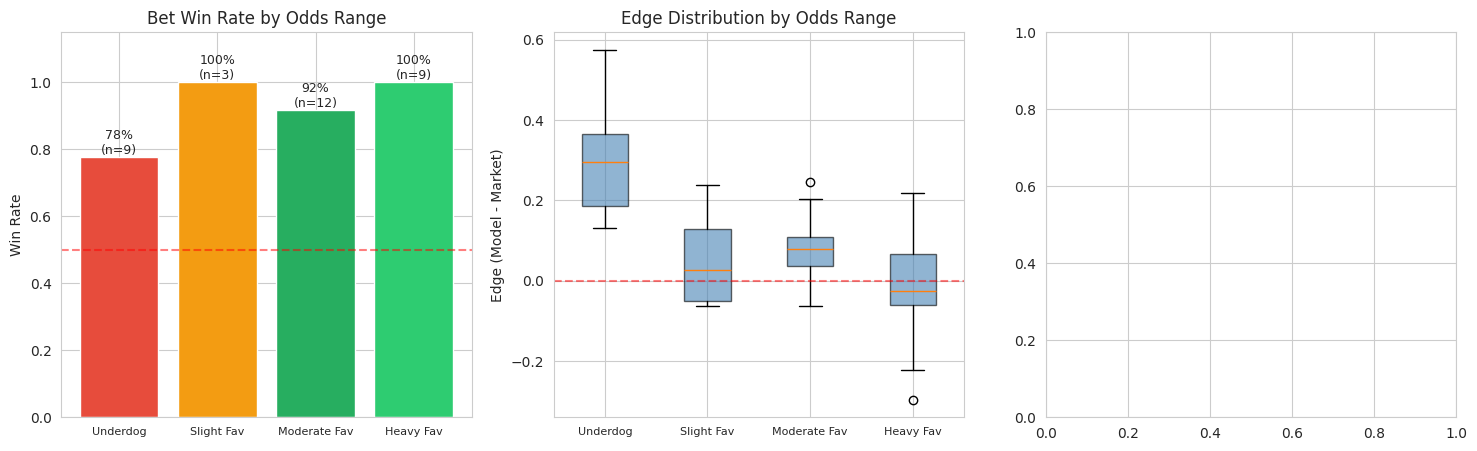

In [9]:
print("=" * 70)
print("RESULTS BY ODDS RANGE")
print("=" * 70)

# Breakdown on ALL qualified bets
bucket_order = ['Underdog (+100 or more)', 'Slight Fav (-100 to -150)', 
                'Moderate Fav (-151 to -250)', 'Heavy Fav (-251 or more)']

print(f"\n{'Odds Range':<30} {'Bets':>5} {'W':>4} {'L':>4} {'Win%':>7} "
      f"{'Avg Edge':>9} {'Avg Odds':>9} {'P&L (½K)':>10} {'ROI (½K)':>9}")
print("=" * 95)

for bucket in bucket_order:
    b = qualified[qualified['odds_bucket'] == bucket]
    if len(b) == 0:
        print(f"{bucket:<30} {'—':>5}")
        continue
    
    stk = calc_stakes(b, BANKROLL, 'half_kelly')
    total_staked = stk['stake'].sum()
    total_pnl = stk['pnl'].sum()
    roi = total_pnl / total_staked * 100 if total_staked > 0 else 0
    
    print(f"{bucket:<30} {len(b):>5} {int(b['won'].sum()):>4} {int((~b['won']).sum()):>4} "
          f"{b['won'].mean():>6.1%} {b['edge'].mean():>+8.1%} {b['american_odds'].mean():>+8.0f} "
          f"${total_pnl:>+9.2f} {roi:>+8.1f}%")

print()

# Same breakdown for ALL fights (not just qualified) to see where model adds value
print(f"\n{'='*70}")
print("MODEL ACCURACY BY ODDS RANGE (ALL FIGHTS)")
print(f"{'='*70}")

print(f"\n{'Odds Range':<30} {'Fights':>7} {'Correct':>8} {'Accuracy':>9} "
      f"{'Avg Model Conf':>15} {'Avg Market Fav':>16}")
print("=" * 90)

for bucket in bucket_order:
    # Classify each fight by the model's picked side odds
    b = bets_df[bets_df['odds_bucket'] == bucket]
    if len(b) == 0:
        print(f"{bucket:<30} {'—':>7}")
        continue
    
    correct = b['won'].sum() if 'won' in b.columns else b['correct'].sum()
    acc = correct / len(b)
    avg_conf = b['model_prob'].mean() if 'model_prob' in b.columns else b['confidence'].mean()
    avg_market = b['market_fair'].mean()
    
    print(f"{bucket:<30} {len(b):>7} {int(correct):>8} {acc:>8.1%} "
          f"{avg_conf:>14.1%} {avg_market:>15.1%}")

# ── Where is the edge? Model prob vs market prob by bucket ──
print(f"\n{'='*70}")
print("EDGE ANALYSIS BY ODDS RANGE")
print(f"{'='*70}")

print(f"\n{'Odds Range':<30} {'Fights':>7} {'Avg Model':>10} {'Avg Market':>11} "
      f"{'Avg Edge':>9} {'Edge>0':>7} {'CLV':>8}")
print("=" * 85)

for bucket in bucket_order:
    b = bets_df[bets_df['odds_bucket'] == bucket]
    if len(b) == 0:
        continue
    
    avg_model = b['model_prob'].mean()
    avg_market = b['market_fair'].mean()
    avg_edge = b['edge'].mean()
    pct_pos = (b['edge'] > 0).mean()
    
    # CLV: did model assign more prob to the actual winner than market?
    clv_vals = []
    for _, r in b.iterrows():
        if r['actual_winner'] == r['fighter_1']:
            clv_vals.append(r['model_p1'] - r['fair_1'])
        else:
            clv_vals.append(r['model_p2'] - r['fair_2'])
    avg_clv = np.mean(clv_vals)
    
    print(f"{bucket:<30} {len(b):>7} {avg_model:>9.1%} {avg_market:>10.1%} "
          f"{avg_edge:>+8.1%} {pct_pos:>6.0%} {avg_clv:>+7.1%}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: win rate by odds bucket (qualified bets)
bucket_data = []
for bucket in bucket_order:
    b = qualified[qualified['odds_bucket'] == bucket]
    if len(b) > 0:
        bucket_data.append({'bucket': bucket.split('(')[0].strip(), 'n': len(b), 
                           'win_pct': b['won'].mean(), 'edge': b['edge'].mean()})

if bucket_data:
    bd = pd.DataFrame(bucket_data)
    colors = ['#e74c3c', '#f39c12', '#27ae60', '#2ecc71'][:len(bd)]
    bars = axes[0].bar(range(len(bd)), bd['win_pct'], color=colors, edgecolor='white')
    for i, (_, row) in enumerate(bd.iterrows()):
        axes[0].text(i, row['win_pct'] + 0.01, f"{row['win_pct']:.0%}\n(n={row['n']})", 
                     ha='center', fontsize=9)
    axes[0].set_xticks(range(len(bd)))
    axes[0].set_xticklabels(bd['bucket'], fontsize=8)
    axes[0].set_ylabel('Win Rate')
    axes[0].set_title('Bet Win Rate by Odds Range')
    axes[0].set_ylim(0, 1.15)
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# Middle: edge distribution by bucket (all fights)
bucket_edges = {}
for bucket in bucket_order:
    b = bets_df[bets_df['odds_bucket'] == bucket]
    if len(b) > 0:
        short = bucket.split('(')[0].strip()
        bucket_edges[short] = b['edge'].values

if bucket_edges:
    axes[1].boxplot(bucket_edges.values(), labels=bucket_edges.keys(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('Edge (Model - Market)')
    axes[1].set_title('Edge Distribution by Odds Range')
    axes[1].tick_params(axis='x', labelsize=8)

# Right: P&L by odds bucket across strategies
bucket_pnl = {}
for name in ['Half Kelly (10% cap)', 'Flat 2%', 'Edge Proportional']:
    method = strategies[name]
    pnl_by_bucket = []
    for bucket in bucket_order:
        b = qualified[qualified['odds_bucket'] == bucket]
        if len(b) > 0:
            stk = calc_stakes(b, BANKROLL, method)
            pnl_by_bucket.append(stk['pnl'].sum())
        else:
            pnl_by_bucket.append(0)
    bucket_pnl[name] = pnl_by_bucket

if bucket_pnl:
    x = np.arange(len(bucket_order))
    width = 0.25
    for i, (name, pnls) in enumerate(bucket_pnl.items()):
        short_labels = [b.split('(')[0].strip() for b in bucket_order]
        axes[2].bar(x + i*width, pnls, width, label=name, alpha=0.8)
    axes[2].set_xticks(x + width)
    axes[2].set_xticklabels(short_labels, fontsize=8)
    axes[2].set_ylabel('P&L ($)')
    axes[2].set_title('P&L by Odds Range × Strategy')
    axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{DATA}backtest_odds_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA}backtest_odds_breakdown.png")

Cell 7

In [ ]:
# Verify backtest fights are NOT in training data
backtest_dates = res['event'].unique()
print("Backtest events:")
for e in sorted(backtest_dates):
    print(f"  {e}")

# Check model_data date range
print(f"\nmodel_data date range: {model_data['event_date'].min()} → {model_data['event_date'].max()}")
print(f"Backtest fights in model_data: check if these events appear in training")

In [ ]:
if len(qualified) > 0:
    # Calculate stakes for both strategies
    fk_stakes = calc_stakes(qualified, BANKROLL, 'full_kelly')
    ep_stakes = calc_stakes(qualified, BANKROLL, 'edge_proportional')
    qualified = qualified.copy()
    qualified['fk_stake'] = fk_stakes['stake'].values
    qualified['fk_pnl'] = fk_stakes['pnl'].values
    qualified['ep_stake'] = ep_stakes['stake'].values
    qualified['ep_pnl'] = ep_stakes['pnl'].values
    
    print(f"{'='*145}")
    print(f"{'Event':<12} {'Pick':<22} {'Odds':>6} {'Model':>7} {'Market':>7} {'Edge':>7} "
          f"{'FK Stake':>9} {'FK P&L':>9} {'EP Stake':>9} {'EP P&L':>9} {'Result':>7}")
    print(f"{'='*145}")
    
    for evt in sorted(qualified['event'].unique()):
        evt_bets = qualified[qualified['event'] == evt].sort_values('edge', ascending=False)
        for _, b in evt_bets.iterrows():
            result_str = 'WIN ✅' if b['won'] else 'LOSS ❌'
            print(f"{b['event']:<12} {b['pick']:<22} {b['american_odds']:>+6.0f} "
                  f"{b['model_prob']:>6.1%} {b['market_fair']:>6.1%} {b['edge']:>+6.1%} "
                  f"${b['fk_stake']:>8.2f} ${b['fk_pnl']:>+8.2f} "
                  f"${b['ep_stake']:>8.2f} ${b['ep_pnl']:>+8.2f} {result_str:>7}")
        evt_fk = evt_bets['fk_pnl'].sum()
        evt_ep = evt_bets['ep_pnl'].sum()
        print(f"{'':>12} {'':>22} {'':>6} {'':>7} {'':>7} {'':>7} "
              f"{'':>9} ${evt_fk:>+8.2f} {'':>9} ${evt_ep:>+8.2f}  ← event total")
        print()
    
    print(f"{'='*145}")
    fk_total_staked = qualified['fk_stake'].sum()
    fk_total_pnl = qualified['fk_pnl'].sum()
    ep_total_staked = qualified['ep_stake'].sum()
    ep_total_pnl = qualified['ep_pnl'].sum()
    record = f"{int(qualified['won'].sum())}W-{int((~qualified['won']).sum())}L"
    print(f"{'TOTAL':<12} {'':<22} {'':>6} {'':>7} {'':>7} {'':>7} "
          f"${fk_total_staked:>8.2f} ${fk_total_pnl:>+8.2f} "
          f"${ep_total_staked:>8.2f} ${ep_total_pnl:>+8.2f} {record:>7}")
    fk_roi = fk_total_pnl / fk_total_staked * 100
    ep_roi = ep_total_pnl / ep_total_staked * 100
    print(f"{'ROI':<12} {'':<22} {'':>6} {'':>7} {'':>7} {'':>7} "
          f"{'':>9} {fk_roi:>+8.1f}% {'':>9} {ep_roi:>+8.1f}%")

Cell 8

In [ ]:
print("=" * 70)
print("MODEL vs MARKET — CLOSING LINE VALUE")
print("=" * 70)

# For every fight (not just qualified), compare model prob to market prob
# If model consistently assigns higher prob to the winner, it has CLV

# Did the model assign higher probability to the actual winner than the market?
clv_rows = []
for _, row in bets_df.iterrows():
    if row['actual_winner'] == row['fighter_1']:
        model_winner_prob = row['model_p1']
        market_winner_prob = row['fair_1']
    else:
        model_winner_prob = row['model_p2']
        market_winner_prob = row['fair_2']
    
    clv_rows.append({
        'event': row['event'],
        'fight': f"{row['fighter_1']} vs {row['fighter_2']}",
        'winner': row['actual_winner'],
        'model_prob': model_winner_prob,
        'market_prob': market_winner_prob,
        'clv': model_winner_prob - market_winner_prob,
        'tier': row['tier'],
    })

clv_df = pd.DataFrame(clv_rows)

print(f"\nAvg model prob assigned to winner: {clv_df['model_prob'].mean():.1%}")
print(f"Avg market prob assigned to winner: {clv_df['market_prob'].mean():.1%}")
print(f"Avg CLV (model - market): {clv_df['clv'].mean():+.1%}")
print(f"CLV positive in {(clv_df['clv'] > 0).sum()}/{len(clv_df)} fights ({(clv_df['clv'] > 0).mean():.1%})")

print(f"\nCLV by tier:")
clv_tier = clv_df.groupby('tier').agg(
    fights=('clv', 'size'),
    avg_clv=('clv', 'mean'),
    pct_positive=('clv', lambda x: (x > 0).mean())
).reindex(['VERY_HIGH', 'HIGH', 'MEDIUM', 'LOW', 'NO_CONF']).dropna(how='all')
clv_tier['avg_clv'] = clv_tier['avg_clv'].apply(lambda x: f"{x:+.1%}")
clv_tier['pct_positive'] = clv_tier['pct_positive'].apply(lambda x: f"{x:.0%}")
print(clv_tier.to_string())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: CLV distribution
axes[0].hist(clv_df['clv'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=clv_df['clv'].mean(), color='green', linestyle='-', linewidth=2, label=f"Mean: {clv_df['clv'].mean():+.1%}")
axes[0].set_xlabel('CLV (Model - Market)')
axes[0].set_ylabel('Count')
axes[0].set_title('Closing Line Value Distribution')
axes[0].legend()

# Middle: model prob vs market prob scatter
ax1 = axes[1]
correct = clv_df[clv_df['model_prob'] > 0.5]  # model "picked" the winner
wrong = clv_df[clv_df['model_prob'] <= 0.5]
ax1.scatter(correct['market_prob'], correct['model_prob'], alpha=0.5, c='green', s=30, label='Model correct')
ax1.scatter(wrong['market_prob'], wrong['model_prob'], alpha=0.5, c='red', s=30, label='Model wrong')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('Market Prob (Winner)')
ax1.set_ylabel('Model Prob (Winner)')
ax1.set_title('Model vs Market — Prob Assigned to Winner')
ax1.legend(fontsize=8)

# Right: cumulative CLV over fights
clv_df_sorted = clv_df.sort_values('event').reset_index(drop=True)
clv_df_sorted['cum_clv'] = clv_df_sorted['clv'].cumsum()
axes[2].plot(clv_df_sorted.index, clv_df_sorted['cum_clv'], 'b-', linewidth=2)
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Fight #')
axes[2].set_ylabel('Cumulative CLV')
axes[2].set_title('Cumulative CLV Over Time')
axes[2].fill_between(clv_df_sorted.index, 0, clv_df_sorted['cum_clv'], 
                     where=clv_df_sorted['cum_clv'] > 0, alpha=0.15, color='green')
axes[2].fill_between(clv_df_sorted.index, 0, clv_df_sorted['cum_clv'], 
                     where=clv_df_sorted['cum_clv'] < 0, alpha=0.15, color='red')

plt.tight_layout()
plt.savefig(f"{DATA}backtest_clv.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA}backtest_clv.png")

Cell 9

In [ ]:
print("=" * 70)
print("BANKROLL SIMULATION")
print("=" * 70)

# Simulate chronological betting with rolling bankroll
# Sort qualified bets by event (chronological)
if len(qualified) > 0:
    sim = qualified.sort_values(['ufc_num']).reset_index(drop=True)
    
    starting_bankroll = BANKROLL
    bankroll = starting_bankroll
    history = [{'fight': 0, 'bankroll': bankroll, 'event': 'Start'}]
    
    for i, row in sim.iterrows():
        # Recalculate stake based on current bankroll
        if row['edge'] > 0 and row['decimal_odds'] > 1:
            kelly_frac = (row['edge'] / (row['decimal_odds'] - 1)) / 2
            kelly_frac = min(kelly_frac, 0.10)  # cap at 10% per bet
        else:
            kelly_frac = 0
        
        stake = kelly_frac * bankroll
        
        if row['won']:
            pnl = stake * (row['decimal_odds'] - 1)
        else:
            pnl = -stake
        
        bankroll += pnl
        history.append({
            'fight': i + 1,
            'bankroll': bankroll,
            'event': row['event'],
            'pick': row['pick'],
            'result': 'W' if row['won'] else 'L',
            'stake': round(stake, 2),
            'pnl': round(pnl, 2),
        })
    
    hist_df = pd.DataFrame(history)
    
    print(f"Starting bankroll: ${starting_bankroll:,.2f}")
    print(f"Final bankroll:    ${bankroll:,.2f}")
    print(f"Net P&L:           ${bankroll - starting_bankroll:+,.2f}")
    print(f"Return:            {(bankroll / starting_bankroll - 1) * 100:+.1f}%")
    print(f"Max bankroll:      ${hist_df['bankroll'].max():,.2f}")
    print(f"Min bankroll:      ${hist_df['bankroll'].min():,.2f}")
    print(f"Max drawdown:      ${hist_df['bankroll'].max() - hist_df['bankroll'].min():,.2f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(hist_df['fight'], hist_df['bankroll'], 'b-o', markersize=5, linewidth=2)
    ax.axhline(y=starting_bankroll, color='gray', linestyle='--', alpha=0.5, label=f'Start: ${starting_bankroll}')
    ax.fill_between(hist_df['fight'], starting_bankroll, hist_df['bankroll'],
                    where=hist_df['bankroll'] >= starting_bankroll, alpha=0.15, color='green')
    ax.fill_between(hist_df['fight'], starting_bankroll, hist_df['bankroll'],
                    where=hist_df['bankroll'] < starting_bankroll, alpha=0.15, color='red')
    
    # Annotate event boundaries
    prev_event = None
    for _, h in hist_df.iterrows():
        if h.get('event') != prev_event and h['fight'] > 0:
            ax.axvline(x=h['fight'], color='gray', linestyle=':', alpha=0.3)
            ax.text(h['fight'], ax.get_ylim()[1], h.get('event', ''), rotation=90, 
                    fontsize=7, va='top', ha='right', alpha=0.5)
        prev_event = h.get('event')
    
    ax.set_xlabel('Bet #')
    ax.set_ylabel('Bankroll ($)')
    ax.set_title('Bankroll Simulation — Qualified Bets Only (Half-Kelly, 10% Cap)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(f"{DATA}backtest_bankroll.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {DATA}backtest_bankroll.png")
else:
    print("No qualified bets to simulate.")

Cell 10

In [ ]:
print("=" * 70)
print("STRATEGY COMPARISON")
print("=" * 70)

# Compare strategies on the full matched sample
strategies = {}

# 1. Always pick favorite (lower implied odds = higher market probability)
fav_correct = 0
for _, row in res.iterrows():
    fav = row['fighter_1'] if row['fair_1'] > row['fair_2'] else row['fighter_2']
    if fav == row['actual_winner']:
        fav_correct += 1
strategies['Always Favorite'] = fav_correct / len(res)

# 2. Always pick f1 (red corner)
strategies['Always Red'] = res.apply(
    lambda r: r['fighter_1'] == r['actual_winner'], axis=1
).mean()

# 3. Model — all fights
strategies['Model (all)'] = res['correct'].mean()

# 4. Model — unanimous only
if len(res[res['unanimous']]) > 0:
    strategies['Model (unanimous)'] = res[res['unanimous']]['correct'].mean()

# 5. Model — HIGH+ tier
high_plus = res[res['tier'].isin(['VERY_HIGH', 'HIGH'])]
if len(high_plus) > 0:
    strategies['Model (HIGH+)'] = high_plus['correct'].mean()

# 6. Qualified bets only
if len(qualified) > 0:
    strategies['Qualified bets'] = qualified['won'].mean()

print(f"\n{'Strategy':<25} {'Accuracy':>10} {'N':>6}")
print("-" * 45)
for name, acc in sorted(strategies.items(), key=lambda x: -x[1]):
    if name == 'Model (all)':
        n = len(res)
    elif name == 'Model (unanimous)':
        n = len(res[res['unanimous']])
    elif name == 'Model (HIGH+)':
        n = len(high_plus)
    elif name == 'Qualified bets':
        n = len(qualified)
    else:
        n = len(res)
    print(f"{name:<25} {acc:>9.1%} {n:>6}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(strategies.keys())
accs = list(strategies.values())
colors = ['#e74c3c' if a < 0.55 else '#f39c12' if a < 0.65 else '#27ae60' if a < 0.75 else '#2ecc71' for a in accs]
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f"{acc:.1%}", va='center', fontsize=10)
ax.set_xlabel('Accuracy')
ax.set_title('Strategy Comparison — Backtest')
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{DATA}backtest_strategies.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {DATA}backtest_strategies.png")

Cell 11

In [ ]:
print("=" * 70)
print("SAVE & SUMMARY")
print("=" * 70)

# Save full results
bets_df.to_csv(f"{DATA}backtest_full.csv", index=False)
print(f"Saved: {DATA}backtest_full.csv ({len(bets_df)} fights)")

if len(qualified) > 0:
    qualified.to_csv(f"{DATA}backtest_qualified.csv", index=False)
    print(f"Saved: {DATA}backtest_qualified.csv ({len(qualified)} bets)")

# Summary stats
print(f"\n{'='*70}")
print(f"BACKTEST SUMMARY")
print(f"{'='*70}")
print(f"Period:              {res['event'].iloc[0]} → {res['event'].iloc[-1]}")
print(f"Events:              {res['event'].nunique()}")
print(f"Total fights:        {len(res)}")
print(f"Model accuracy:      {res['correct'].mean():.1%}")
if len(unan) > 0:
    print(f"Unanimous accuracy:  {unan['correct'].mean():.1%} ({len(unan)} fights)")
print(f"Avg CLV:             {clv_df['clv'].mean():+.1%}")

if len(qualified) > 0:
    total_staked = qualified['stake'].sum()
    total_pnl = qualified['pnl'].sum()
    roi = total_pnl / total_staked * 100 if total_staked > 0 else 0
    print(f"\nBetting:")
    print(f"  Qualified bets:    {len(qualified)}")
    print(f"  Record:            {qualified['won'].sum()}W - {(~qualified['won']).sum()}L ({qualified['won'].mean():.1%})")
    print(f"  Total staked:      ${total_staked:,.2f}")
    print(f"  Total P&L:         ${total_pnl:+,.2f}")
    print(f"  ROI:               {roi:+.1f}%")

print(f"\n⚠️  SAMPLE SIZE WARNING:")
print(f"  {len(res)} fights is too small for statistical significance.")
print(f"  A model with true 79% accuracy could show 71-87% on n={len(res)} (95% CI).")
if len(qualified) > 0:
    print(f"  {len(qualified)} bets is insufficient to confirm betting edge.")
    print(f"  Continue tracking live results over 10-15+ events for validation.")

print(f"\nFiles saved:")
print(f"  {DATA}backtest_full.csv")
if len(qualified) > 0:
    print(f"  {DATA}backtest_qualified.csv")
print(f"  {DATA}backtest_accuracy.png")
print(f"  {DATA}backtest_clv.png")
print(f"  {DATA}backtest_bankroll.png")
print(f"  {DATA}backtest_strategies.png")

In [ ]:
cutoff = pd.Timestamp('2025-07-01')

for evt in sorted(res['event'].unique()):
    ufc_num = int(re.search(r'\d+', evt).group())
    evt_fights = model_data[model_data['event_name'].str.contains(f'UFC {ufc_num}', case=False, na=False)]
    if len(evt_fights) > 0:
        evt_date = evt_fights['event_date'].iloc[0]
        split = "FAIR ✅" if evt_date >= cutoff else "LEAKED ❌"
        n_odds = len(res[res['event'] == evt])
        print(f"  {evt:<12} {str(evt_date.date()):<12} {split}  ({n_odds} fights)")
    else:
        print(f"  {evt:<12} NOT FOUND")